GPU is available
Using device: NVIDIA GeForce RTX 3090
Training with hidden_channels=128, learning_rate=0.001, weight_decay=1e-05, epochs=150
Epoch 10/150, Loss: 0.0306
Epoch 20/150, Loss: 0.0305
Epoch 30/150, Loss: 0.0305
Epoch 40/150, Loss: 0.0304
Epoch 50/150, Loss: 0.0304
Epoch 60/150, Loss: 0.0304
Epoch 70/150, Loss: 0.0304
Epoch 80/150, Loss: 0.0304
Early stopping at epoch 82


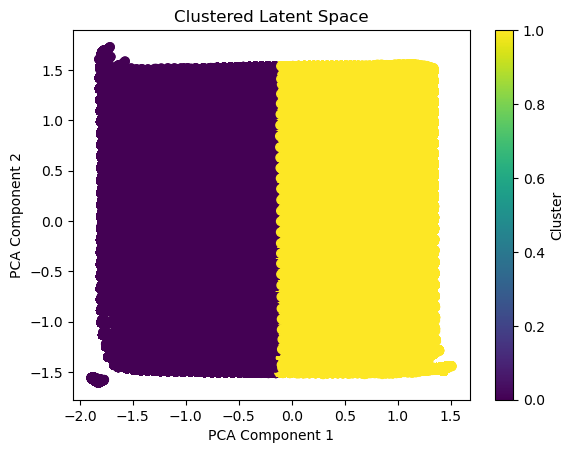

In [4]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from sklearn.model_selection import KFold

if torch.cuda.is_available():
    print("GPU is available")
    print(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, using CPU")
    
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Data paths
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defectlabel4x4/DefectLabels_4x4_test1"

# Load coordinate data
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# Load edge information
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# Data and label files
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# Function to extract layer and block information from filenames
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # No defect data
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"Invalid file name format: {file_name}")
        return None

# Prepare data pairs
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# Valid pairs and adding defect-free data
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]
defect_free_pair = ("/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy",
                    "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy")

for _ in range(14850):
    valid_pairs.append(defect_free_pair)

# Prepare data
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # Load data and labels
        try:
            values = np.load(data_file_path)[:3654]
            label = np.load(label_file_path)[:3654]
        except Exception as e:
            print(f"Error loading data: {e}")
            continue
        
        # Create node features by combining coordinate and stress data
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    if len(sampled_data) == 0 or len(sampled_labels) == 0:
        print("No valid data found in the pairs.")
        return None

    # Convert to tensor
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)
    y = torch.tensor(sampled_labels, dtype=torch.float).to(device)

    return x, y

all_x, all_y = prepare_data(valid_pairs)

# Create Data objects for each sample
all_data_list = []
num_all_samples = all_x.shape[0] // 3654
for i in range(num_all_samples):
    all_data_list.append(Data(x=all_x[i * 3654:(i + 1) * 3654], edge_index=edge_index, y=all_y[i * 3654:(i + 1) * 3654]))

# Use DataLoader for memory efficiency
batch_size = 32
train_data, test_data = train_test_split(all_data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Define GVAE model class
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(Encoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Normalization
        self.dropout = nn.Dropout(p=0.3)  # Dropout
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv_mu = GCNConv(hidden_channels * 2, hidden_channels)
        self.conv_logstd = GCNConv(hidden_channels * 2, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

class Decoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super(Decoder, self).__init__()
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, z):
        return self.linear(z)

# Training with hyperparameters and early stopping
hidden_channels_list = [128]
learning_rate_list = [1e-3]
weight_decay_list = [1e-5]
epochs_list = [150]
patience = 10  # Early stopping patience
best_loss = float('inf')
epochs_no_improve = 0

# Grid search over all combinations of hyperparameters
for hidden_channels in hidden_channels_list:
    for learning_rate in learning_rate_list:
        for weight_decay in weight_decay_list:
            for epochs in epochs_list:
                print(f"Training with hidden_channels={hidden_channels}, learning_rate={learning_rate}, weight_decay={weight_decay}, epochs={epochs}")
                
                encoder = Encoder(in_channels=4, hidden_channels=hidden_channels).to(device)
                decoder = Decoder(hidden_channels=hidden_channels, out_channels=4).to(device)
                model = VGAE(encoder).to(device)
                optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate, weight_decay=weight_decay)
                scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)  # Learning rate scheduler

                def loss_fn(recon_x, x, mu, logstd):
                    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
                    kl_divergence = -0.5 * torch.mean(1 + 2 * logstd - mu.pow(2) - (2 * logstd).exp())
                    return recon_loss + kl_divergence

                for epoch in range(1, epochs + 1):
                    model.train()
                    total_loss = 0
                    for data in train_loader:
                        data = data.to(device)
                        optimizer.zero_grad()
                
                        # VGAE modelにデータを直接渡す
                        z = model.encode(data.x, data.edge_index)  # VGAEのエンコードで潜在変数zを取得
                        recon = decoder(z)  # 潜在変数zをデコーダに渡して再構成
                
                        # エンコーダからの出力で損失関数を計算
                        mu, logstd = model.__mu__, model.__logstd__  # VGAEが内部で持っている属性を使用
                        loss = loss_fn(recon, data.x, mu, logstd)
                        
                        loss.backward()
                        optimizer.step()
                        total_loss += loss.item()
                
                    avg_loss = total_loss / len(train_loader)
                    scheduler.step()  # 学習率の更新
                
                    if epoch % 10 == 0:
                        print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")
                
                    # Early stopping のチェック
                    if avg_loss < best_loss:
                        best_loss = avg_loss
                        epochs_no_improve = 0
                        torch.save(model.state_dict(), f'/home/nishioka/GNN/GNNmodel/gvae_model_best_{timestamp}.pth')
                    else:
                        epochs_no_improve += 1
                
                    if epochs_no_improve >= patience:
                        print(f"Early stopping at epoch {epoch}")
                        break

model.eval()
z_encoded = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        
        # VGAEのencodeメソッドを使って潜在変数zを取得
        z = model.encode(data.x, data.edge_index)  # VGAEが自動でreparameterizeを行う
        
        z_encoded.append(z.cpu().numpy())  # 潜在変数をnumpyに変換して格納

# z_encodedをnumpy配列に変換
z_encoded = np.vstack(z_encoded)

# Clustering the encoded latent space
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(z_encoded)

# Visualizing the clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_encoded)
plt.scatter(z_pca[:, 0], z_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clustered Latent Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.savefig(f'/home/nishioka/GNN/GNNmodelgraphfig/gvae_cluster_{timestamp}.png')
plt.show()

GPU is available
Using device: NVIDIA GeForce RTX 3090
Epoch 1/2, Loss: 0.008991243056919045
Epoch 2/2, Loss: 0.0013600972575588757


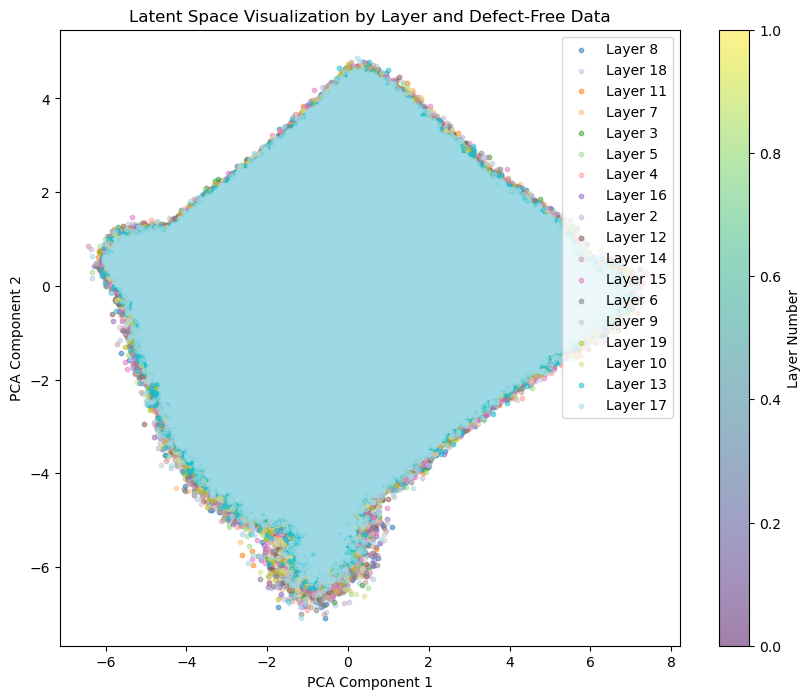

In [3]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import datetime

if torch.cuda.is_available():
    print("GPU is available")
    print(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, using CPU")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Data paths
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defectlabel4x4/DefectLabels_4x4_test1"

# Load coordinate data
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# Load edge information
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# Data and label files
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# Function to extract layer and block information from filenames
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # No defect data
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"Invalid file name format: {file_name}")
        return None

# Prepare data pairs
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# Valid pairs and adding defect-free data
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]
defect_free_pair = ("/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy",
                    "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy")

for _ in range(14850):
    valid_pairs.append(defect_free_pair)

# Prepare data
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # Load data and labels
        try:
            values = np.load(data_file_path)[:3654]
            label = np.load(label_file_path)[:3654]
        except Exception as e:
            print(f"Error loading data: {e}")
            continue
        
        # Create node features by combining coordinate and stress data
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    if len(sampled_data) == 0 or len(sampled_labels) == 0:
        print("No valid data found in the pairs.")
        return None

    # Convert to tensor
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)
    y = torch.tensor(sampled_labels, dtype=torch.float).to(device)

    return x, y

all_x, all_y = prepare_data(valid_pairs)

# Create Data objects for each sample
all_data_list = []
num_all_samples = all_x.shape[0] // 3654
for i in range(num_all_samples):
    data_file = data_files[i % len(data_files)]  # 正しくファイル名を取得
    data_obj = Data(x=all_x[i * 3654:(i + 1) * 3654], edge_index=edge_index, y=all_y[i * 3654:(i + 1) * 3654])
    
    # setattrを使ってfile_name属性を追加
    setattr(data_obj, 'file_name', str(data_file))
    
    all_data_list.append(data_obj)

# Use DataLoader for memory efficiency
batch_size = 16
train_data, test_data = train_test_split(all_data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Define GVAE model class
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(Encoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Normalization
        self.dropout = nn.Dropout(p=0.3)  # Dropout
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv_mu = GCNConv(hidden_channels * 2, hidden_channels)
        self.conv_logstd = GCNConv(hidden_channels * 2, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

class Decoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super(Decoder, self).__init__()
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, z):
        return self.linear(z)

hidden_channels=256
learning_rate=0.001
weight_decay=0.00001

encoder = Encoder(in_channels=4, hidden_channels=hidden_channels).to(device)
decoder = Decoder(hidden_channels=hidden_channels, out_channels=4).to(device)
model = VGAE(encoder).to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)  # Learning rate scheduler

def loss_fn(recon_x, x, mu, logstd):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_divergence = -0.5 * torch.mean(1 + 2 * logstd - mu.pow(2) - (2 * logstd).exp())
    return recon_loss + kl_divergence

# Training loop (with 20 epochs)
epochs = 2  # エポック数を20に設定
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        z = model.encode(data.x, data.edge_index)
        recon_x = decoder(z)
        loss = F.mse_loss(recon_x, data.x)  # reconstruction loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader)}")

# Clustering and visualization
layer_wise_encoded = {}
defect_free_encoded = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        # データがリストかどうかを確認し、リストの場合は最初のファイル名を取得
        if isinstance(data.file_name, list):
            file_name = data.file_name[0]  # 最初のファイル名を取得
        else:
            file_name = data.file_name

        # ファイル名の型と値を確認（デバッグ用）
        # print(f"file_name type: {type(file_name)}, value: {file_name}")

        # VGAEのencodeメソッドを使って潜在変数zを取得
        z = model.encode(data.x, data.edge_index)

        # ファイル名から層番号を取得
        layer_block_info = extract_layer_block(file_name)
        if layer_block_info:
            layer_number, _ = layer_block_info

            if layer_number == 0:
                defect_free_encoded.append(z.cpu().numpy())
            else:
                if layer_number not in layer_wise_encoded:
                    layer_wise_encoded[layer_number] = []
                layer_wise_encoded[layer_number].append(z.cpu().numpy())


# 各層の潜在変数をnumpy配列に変換
for layer_number in layer_wise_encoded:
    layer_wise_encoded[layer_number] = np.vstack(layer_wise_encoded[layer_number])

if defect_free_encoded:
    defect_free_encoded = np.vstack(defect_free_encoded)
else:
    defect_free_encoded = np.array([])

# PCAで次元削減
if defect_free_encoded.size > 0:
    all_encoded = np.vstack(list(layer_wise_encoded.values()) + [defect_free_encoded])
else:
    all_encoded = np.vstack(list(layer_wise_encoded.values()))

pca = PCA(n_components=2)
pca.fit(all_encoded)

# PCAで次元削減
if defect_free_encoded.size > 0:
    all_encoded = np.vstack(list(layer_wise_encoded.values()) + [defect_free_encoded])
else:
    all_encoded = np.vstack(list(layer_wise_encoded.values()))

pca = PCA(n_components=2)
pca.fit(all_encoded)

plt.figure(figsize=(10, 8))  # プロットのサイズを少し大きく設定

# 点のサイズと透明度の調整
point_size = 1  # 点のサイズを小さく設定
alpha_value = 0.3  # 透明度を少し高めに設定

# 欠陥なしデータのプロット
if defect_free_encoded.size > 0:
    defect_free_pca = pca.transform(defect_free_encoded)
    plt.scatter(defect_free_pca[:, 0], defect_free_pca[:, 1], color='black', label='Defect-Free Data', s=point_size, alpha=alpha_value)

# 修正済みのカラーマップの取得
colors = plt.get_cmap('tab20', len(layer_wise_encoded))

# 層ごとのデータをプロット
for idx, (layer_number, encoded_data) in enumerate(layer_wise_encoded.items()):
    z_pca = pca.transform(encoded_data)
    plt.scatter(z_pca[:, 0], z_pca[:, 1], label=f'Layer {layer_number}', color=colors(idx), s=point_size, alpha=alpha_value)

# 凡例の位置を右上に指定
plt.legend(loc='upper right')

plt.title('Latent Space Visualization by Layer and Defect-Free Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Layer Number')

# プロットの保存
plt.savefig(f'/home/nishioka/GNN/GNNmodelgraphfig/gvae_layerwise_defectfree_{timestamp}.png')
plt.show()

In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import datetime

if torch.cuda.is_available():
    print("GPU is available")
    print(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, using CPU")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Data paths
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defectlabel4x4/DefectLabels_4x4_test1"

# Load coordinate data
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# Load edge information
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# Data and label files
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# Function to extract layer and block information from filenames
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # No defect data
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"Invalid file name format: {file_name}")
        return None

# Prepare data pairs
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# Valid pairs and adding defect-free data
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]
defect_free_pair = ("/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy",
                    "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy")

for _ in range(14850):
    valid_pairs.append(defect_free_pair)

# Prepare data
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # Load data and labels
        try:
            values = np.load(data_file_path)[:3654]
            label = np.load(label_file_path)[:3654]
        except Exception as e:
            print(f"Error loading data: {e}")
            continue
        
        # Create node features by combining coordinate and stress data
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    if len(sampled_data) == 0 or len(sampled_labels) == 0:
        print("No valid data found in the pairs.")
        return None

    # Convert to tensor
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)
    y = torch.tensor(sampled_labels, dtype=torch.float).to(device)

    return x, y

all_x, all_y = prepare_data(valid_pairs)

# Create Data objects for each sample
all_data_list = []
num_all_samples = all_x.shape[0] // 3654
for i in range(num_all_samples):
    data_file = data_files[i % len(data_files)]  # 正しくファイル名を取得
    data_obj = Data(x=all_x[i * 3654:(i + 1) * 3654], edge_index=edge_index, y=all_y[i * 3654:(i + 1) * 3654])
    
    # setattrを使ってfile_name属性を追加
    setattr(data_obj, 'file_name', str(data_file))
    
    all_data_list.append(data_obj)

# Use DataLoader for memory efficiency
batch_size = 32
train_data, test_data = train_test_split(all_data_list, test_size=0.2, random_state=42)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Define GVAE model class
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(Encoder, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Normalization
        self.dropout = nn.Dropout(p=0.3)  # Dropout
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv_mu = GCNConv(hidden_channels * 2, hidden_channels)
        self.conv_logstd = GCNConv(hidden_channels * 2, hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

class Decoder(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super(Decoder, self).__init__()
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, z):
        return self.linear(z)

hidden_channels=1024
learning_rate=0.001
weight_decay=0.00001

encoder = Encoder(in_channels=4, hidden_channels=hidden_channels).to(device)
decoder = Decoder(hidden_channels=hidden_channels, out_channels=4).to(device)
model = VGAE(encoder).to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)  # Learning rate scheduler

def loss_fn(recon_x, x, mu, logstd):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_divergence = -0.5 * torch.mean(1 + 2 * logstd - mu.pow(2) - (2 * logstd).exp())
    return recon_loss + kl_divergence

# Training loop (with 20 epochs)
epochs = 200  # エポック数を20に設定
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        z = model.encode(data.x, data.edge_index)
        recon_x = decoder(z)
        loss = F.mse_loss(recon_x, data.x)  # reconstruction loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
                        print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")
    
    # print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader)}")

# Clustering and visualization
layer_wise_encoded = {}
defect_free_encoded = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        # データがリストかどうかを確認し、リストの場合は最初のファイル名を取得
        if isinstance(data.file_name, list):
            file_name = data.file_name[0]  # 最初のファイル名を取得
        else:
            file_name = data.file_name

        # ファイル名の型と値を確認（デバッグ用）
        # print(f"file_name type: {type(file_name)}, value: {file_name}")

        # VGAEのencodeメソッドを使って潜在変数zを取得
        z = model.encode(data.x, data.edge_index)

        # ファイル名から層番号を取得
        layer_block_info = extract_layer_block(file_name)
        if layer_block_info:
            layer_number, _ = layer_block_info

            if layer_number == 0:
                defect_free_encoded.append(z.cpu().numpy())
            else:
                if layer_number not in layer_wise_encoded:
                    layer_wise_encoded[layer_number] = []
                layer_wise_encoded[layer_number].append(z.cpu().numpy())


# 各層の潜在変数をnumpy配列に変換
for layer_number in layer_wise_encoded:
    layer_wise_encoded[layer_number] = np.vstack(layer_wise_encoded[layer_number])

if defect_free_encoded:
    defect_free_encoded = np.vstack(defect_free_encoded)
else:
    defect_free_encoded = np.array([])

# PCAで次元削減
if defect_free_encoded.size > 0:
    all_encoded = np.vstack(list(layer_wise_encoded.values()) + [defect_free_encoded])
else:
    all_encoded = np.vstack(list(layer_wise_encoded.values()))

pca = PCA(n_components=2)
pca.fit(all_encoded)

if defect_free_encoded.size > 0:
    defect_free_pca = pca.transform(defect_free_encoded)
    plt.scatter(defect_free_pca[:, 0], defect_free_pca[:, 1], color='black', label='Defect-Free Data')

# 修正済みのカラーマップの取得
colors = plt.get_cmap('tab20', len(layer_wise_encoded))

plt.figure(figsize=(8, 6))
for idx, (layer_number, encoded_data) in enumerate(layer_wise_encoded.items()):
    z_pca = pca.transform(encoded_data)
    plt.scatter(z_pca[:, 0], z_pca[:, 1], label=f'Layer {layer_number}', color=colors(idx), alpha=0.3)

# 凡例の位置を右上に指定
plt.legend(loc='upper right')

plt.title('Latent Space Visualization by Layer and Defect-Free Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Layer Number')

# プロットの保存
plt.savefig(f'/home/nishioka/GNN/GNNmodelgraphfig/gvae_layerwise_defectfree_{timestamp}.png')
plt.show()